## 嵌套饼图可以表达多层嵌套data的占比关系。其主体为多层同心圆环结构，内环表示主分类（如dataA、dataB、dataC），外环表示主分类下的子分类（如dataA-1、dataA-2等）


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def load_style():
    """加载样式文件（如果存在），并设置中文字体支持"""
    # 设置样式
    try:
        plt.style.use("scatter.mplstyle")
    except:
        pass
    # 使用Nature常用的无衬线字体，Ubuntu系统兼容
    plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
    plt.rcParams["axes.unicode_minus"] = False

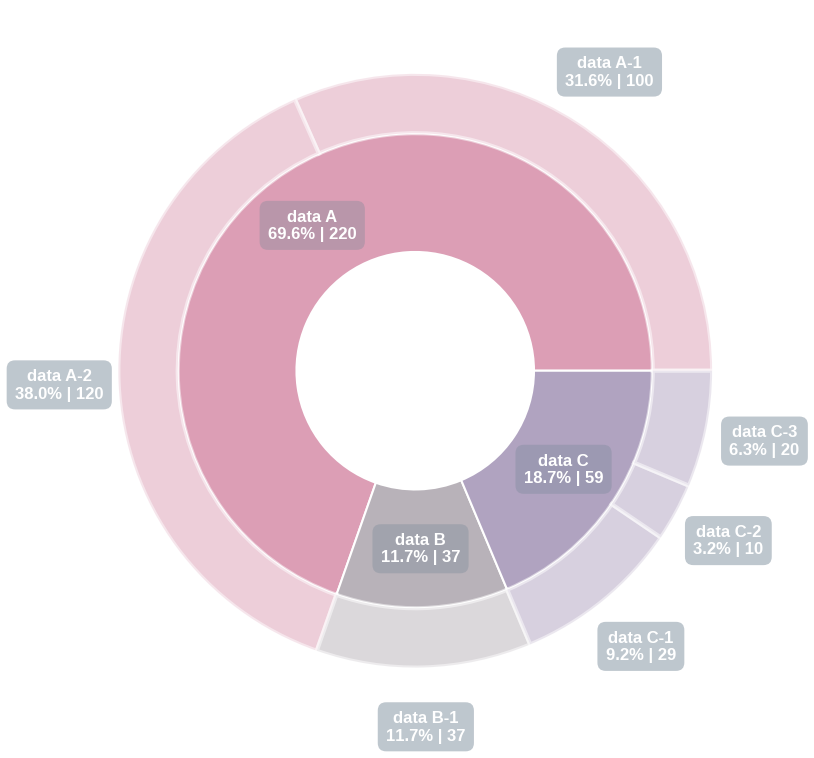

In [ ]:
def create_chart(ax):
    """创建嵌套饼图（基于极坐标的环形图）"""
    # 配置颜色和分类名称
    color = ["#dc9eb5", "#b8b2b9", "#b0a3c0", "#e3d0d7", "#ebe8f0"]
    bgcolor = "#ffffff"
    main_name = ["data A", "data B", "data C"]
    sub_name = ["data A-1", "data A-2", "data B-1", "data C-1", "data C-2", "data C-3"]
    value_list = [[100.0, 120.0], [37.0], [29.0, 10.0, 20]]  # 主分类及子分类data
    
    size = 0.2  # 环形图每层宽度
    ax.set_ylim(0, 0.6)  # 设置极坐标范围
    ax.set_axis_off()    # 隐藏坐标轴
    
    # 计算总data和主分类角度（弧度）
    sum_vals = sum(map(sum, value_list))  # 所有data总和
    main_divided = [sum(sublist) / sum_vals * 2 * np.pi for sublist in value_list]
    main_x = np.cumsum([0] + main_divided[:-1])  # 主分类起始角度
    
    # 绘制主分类条形图（极坐标下的环形层）
    main_colors = color[:len(value_list)]
    main_bars = ax.bar(
        x=main_x, 
        width=main_divided, 
        bottom=size, 
        height=size,
        color=main_colors, 
        edgecolor=bgcolor, 
        linewidth=1, 
        align="edge"
    )
    
    # 展开子分类data，计算子分类角度和起始位置
    sub_values = [val for sublist in value_list for val in sublist]
    sub_divided = [x / sum_vals * 2 * np.pi for x in sub_values]
    sub_x = np.cumsum([0] + sub_divided[:-1])  # 子分类起始角度
    # 子分类颜色（继承主分类颜色）
    sub_colors = [main_colors[i] for i, sublist in enumerate(value_list) for _ in sublist]
    
    # 绘制子分类条形图（极坐标下的内层环形）
    sub_bars = ax.bar(
        x=sub_x, 
        width=sub_divided, 
        bottom=2 * size, 
        height=size * 0.5,
        color=sub_colors, 
        alpha=0.5, 
        edgecolor=bgcolor, 
        linewidth=2, 
        align="edge"
    )
    
    # 为主分类添加标签
    text_attr = {"ha": "center", "va": "center", "fontweight": "bold"}
    for bar, label, val in zip(main_bars, main_name, map(sum, value_list)):
        angle = bar.get_x() + bar.get_width() / 2  # 标签角度（中心位置）
        distance = bar.get_height() + bar.get_y()   # 标签半径（条形顶部）
        # 格式化标签文本：名称 + 百分比 + 原始值
        percentage = f"{label}\n{val / sum_vals * 100:.1f}% | {val:.0f}"
        ax.text(
            angle, 
            distance - 0.1, 
            percentage, 
            color="#ffffff", 
            fontsize=8, 
            **text_attr
        ).set_bbox({
            "facecolor": "#75879655", 
            "edgecolor": "none", 
            "boxstyle": "round,pad=0.5"
        })
    
    # 为子分类添加标签
    for bar, label, val in zip(sub_bars, sub_name, sub_values):
        angle = bar.get_x() + bar.get_width() / 2  # 标签角度（中心位置）
        distance = bar.get_height() + bar.get_y()   # 标签半径（条形顶部）
        # 格式化标签文本：名称 + 百分比 + 原始值
        percentage = f"{label}\n{val / sum_vals * 100:.1f}% | {val:.0f}"
        ax.text(
            angle, 
            distance + 0.1, 
            percentage, 
            color="#ffffff", 
            fontsize=8, 
            **text_attr
        ).set_bbox({
            "facecolor": "#75879677", 
            "edgecolor": "none", 
            "boxstyle": "round,pad=0.5"
        })
    
    # 添加图表标题
    fig = ax.get_figure()
    # fig.text(
    #     0.15, 0.5, "嵌套饼图", 
    #     fontsize=24, 
    #     **text_attr, 
    #     rotation=90, 
    #     va="center"
    # )
    plt.subplots_adjust(left=0.3, right=1.0, top=1.0, bottom=0.05)
    # plt.savefig('./Fig.pdf', dpi=300, bbox_inches='tight')    

if __name__ == "__main__":
    load_style()
    # 创建极坐标子图
    fig, ax = plt.subplots(
        subplot_kw={"projection": "polar"}, 
        figsize=(8, 5), 
        dpi=150
    )
    create_chart(ax)
    plt.show()